
# Sympy notebook with the convolution
In this notebook we use *sympy*, a CAS for python, to calculate the convolution of an
gaussian with an one-sided decaying exponential. Since *sympy* is not an requirement of
*skultrafast*, it may be manually installed.

from [Sympy notebook with the convolution](https://skultrafast.readthedocs.io/en/stable/auto_examples/convolution.html)


In [1]:
import sympy
from sympy import (symbols, Heaviside, exp, sqrt, oo, integrate, simplify, Eq,
                   plot, pi, init_printing, solve)
from sympy import erfc, erf
init_printing()

First, we need to define sympy symbols.



In [2]:
A, t, ti = symbols('A t ti', real=True)
tau, sigma = symbols('tau sigma', positive=True)
step = Heaviside

Define $y=A\exp(-t/\tau)$ and the Gaussian IRF.



In [3]:
y = step(t) * A * exp(-t / tau)
y

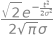

In [4]:
irf = 1 / sqrt(2 * pi * sigma**2) * exp(-t**2 / (2 * sigma**2))
irf

Calculate the covolution integral.



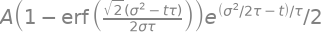

In [ ]:
func = integrate((irf.subs(t, t - ti) * y.subs(t, ti)), (ti, -oo, oo))
func = simplify(func)
func

Rewrite the `erf` with the `erfc` function:
erfc, erf = special.error_functions.erfc, special.error_functions.erf



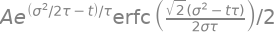

In [6]:
func2 = func.rewrite(erfc)
func2

Plot the result for visualization:



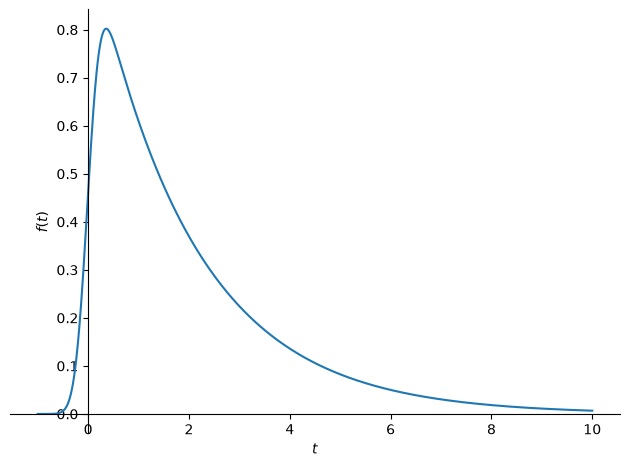

In [7]:
plot(func2.subs(sigma, 0.2).subs(tau, 2).subs(A, 1), (t, -1, 10))

## Normalized derivatives of a Gaussian
These are used to model coherent contributions.



exp(-t**2/(2*sigma**2))
-t*exp(1/2)*exp(-t**2/(2*sigma**2))/sigma
(1 - t**2/sigma**2)*exp(-t**2/(2*sigma**2))


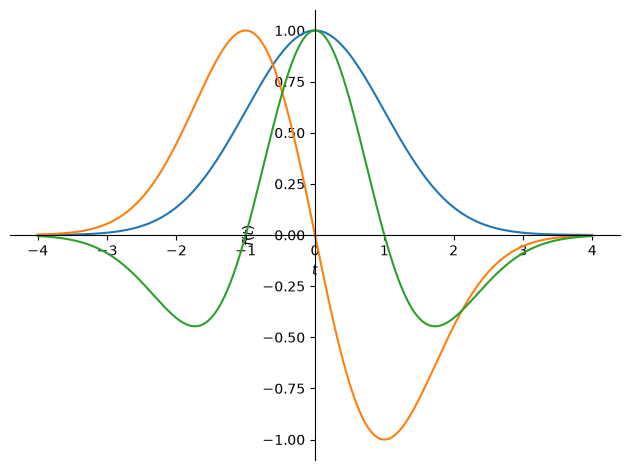

In [8]:
irf, irf.diff(t, 1), irf.diff(t, 2)

p1 = None
for i in range(0, 3):
    f = irf.diff(t, i)
    sol = solve(f.diff(t, 1), t)
    ext = f.subs(t, sol[0])
    if not p1:
        p1 = plot((f/ext).subs(sigma, 1), (t, -4, 4), show=False)
    else:
        p1.append(plot((f/ext).subs(sigma, 1), (t, -4, 4), show=False)[0])
    print((f/ext))
p1.show()

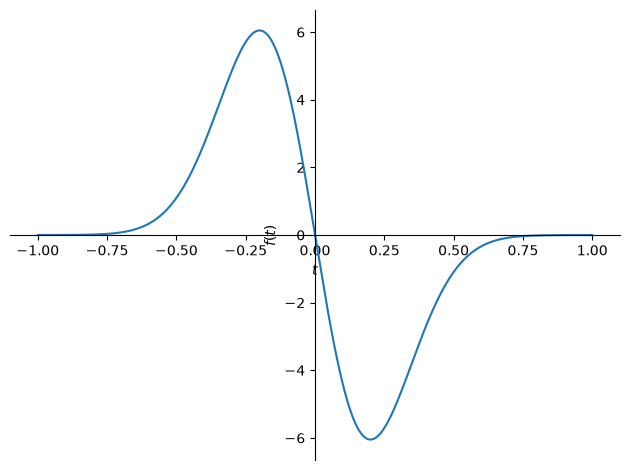

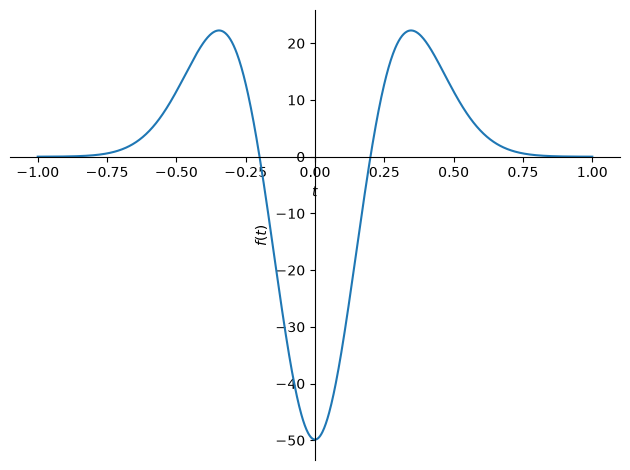

In [9]:
plot(irf.diff(t).subs(sigma, 0.2).subs(tau, 2), (t, -1, 1))
plot(irf.diff(t, 2).subs(sigma, 0.2).subs(tau, 2), (t, -1, 1))